In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

SMALL_SIZE = 13
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen", "fargo_fiducial_companion" ]
titles = ["fiducial", "$M_p = 10 M_{jup}$", "$M_p = 2 M_{Jup}$", "$\\alpha = 10^{-2}$", "$\\alpha = 10^{-4}$", "$\\gamma = 0$",
          "$\\gamma = 0.5$", "$\\gamma = -2$", "$\\gamma = 1.5$"]
paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [3]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

/scratch/3208986/ipykernel_3170437/243733328.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[0][-1]),cmap=cm.Oranges_r)


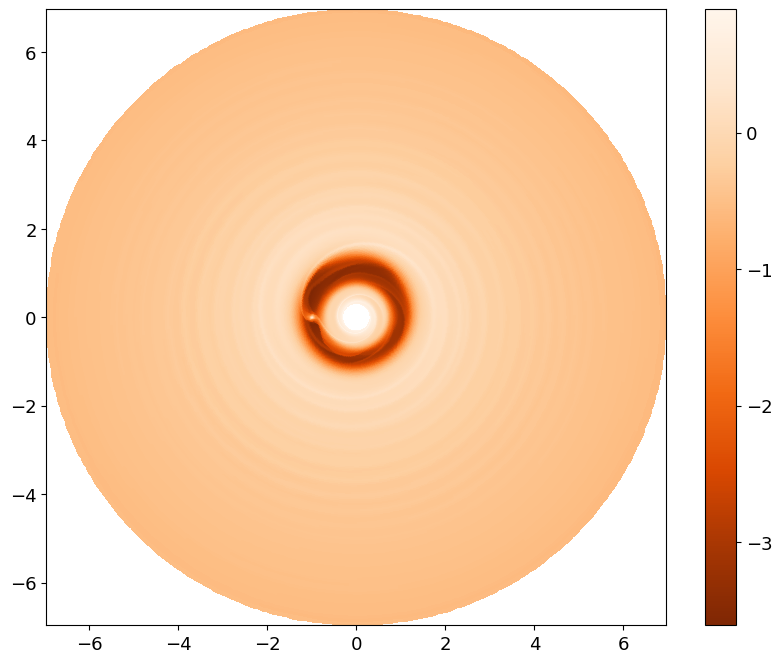

In [4]:
## make this a round plot so I know what's going on.

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
philist = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, philist, indexing='ij')

X = R*np.cos(PHI)
Y = R*np.sin(PHI)

plt.figure(figsize=(10,8))
plt.pcolormesh(X, Y,np.log10(rho_cube[0][-1]),cmap=cm.Oranges_r)
plt.colorbar()

# Cutting out a piece

[0.86631022 1.15024764]
[2.80528639 3.4943041 ]


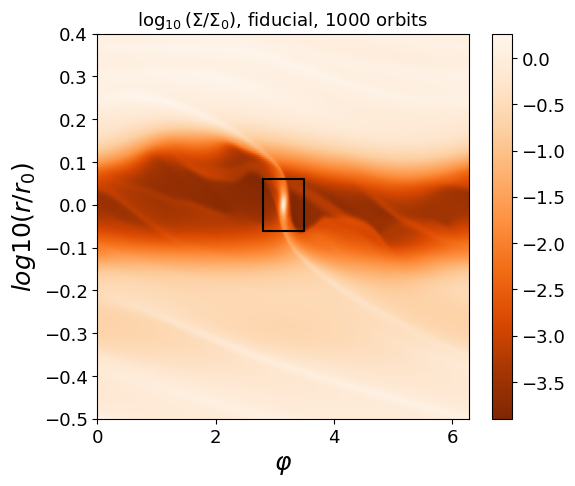

In [5]:
%matplotlib inline
r_min = 0.3
r_max = 7

r_cut = [101,128]
phi_cut = [171,213]
r_in_log = np.log10(r_list[r_cut[1]])
r_out_log = np.log10(r_list[r_cut[0]])
phi_left = philist[phi_cut[0]]
phi_right = philist[phi_cut[1]]


lim = 0.5

plt.figure(figsize=(6,5))
frame = 100

for it,i in enumerate([0]):
    path = paths[i]
        
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])#,clim = (np.log10(lim+0.01),np.log10(lim-0.01)))
    plt.plot([phi_left, phi_right, phi_right, phi_left, phi_left],[r_in_log,r_in_log, r_out_log, r_out_log, r_in_log], color="k")
    
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {titles[i]}, {(frame)*10} orbits")
    plt.ylim(-0.5,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()
plt.savefig("img/cut-out-piece-gap-depth.png", bbox_inches="tight")

print(r_list[r_cut])
print(philist[phi_cut])

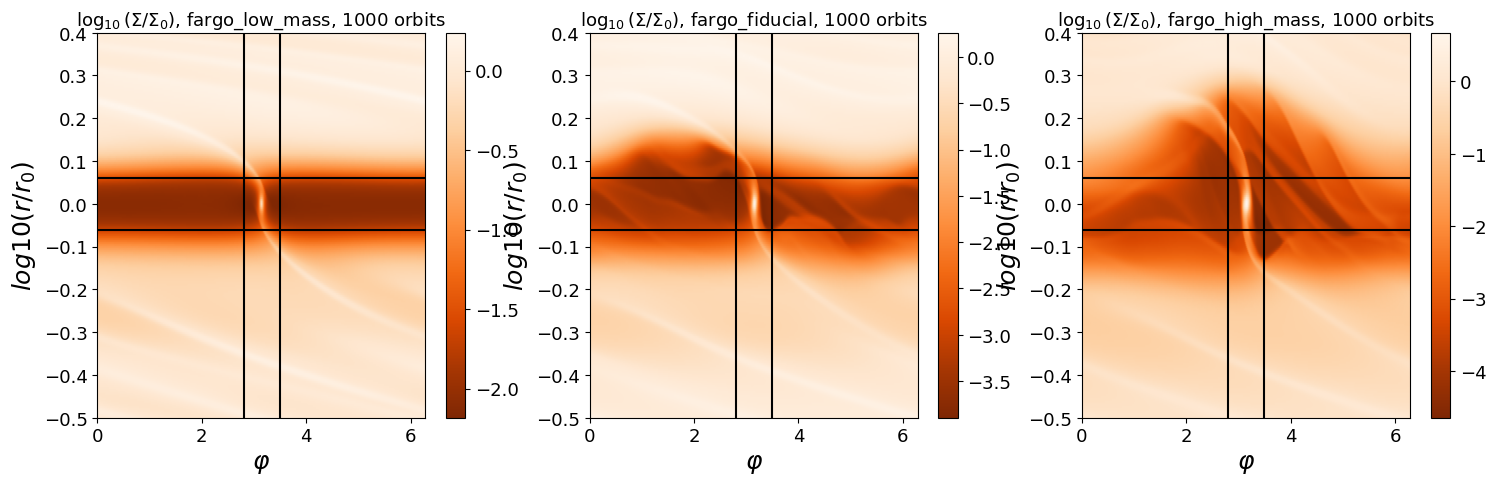

In [6]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_mass=[2,0,1]

r_cut = [101,128]
phi_cut = [171,213]
r_in_log = np.log10(r_list[r_cut[1]])
r_out_log = np.log10(r_list[r_cut[0]])
phi_left = philist[phi_cut[0]]
phi_right = philist[phi_cut[1]]


lim = 0.5

plt.figure(figsize=(18,5))
frame = 100

for it,i in enumerate(index_for_mass):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])#,clim = (np.log10(lim+0.01),np.log10(lim-0.01)))
    plt.plot([0,np.pi*2],[r_in_log,r_in_log], color="k")
    plt.plot([0,np.pi*2],[r_out_log,r_out_log], color="k")
    plt.plot([phi_left, phi_left],[-0.5,0.8], color="k")
    plt.plot([phi_right, phi_right],[-0.5,0.8], color="k")
    
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(-0.5,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()

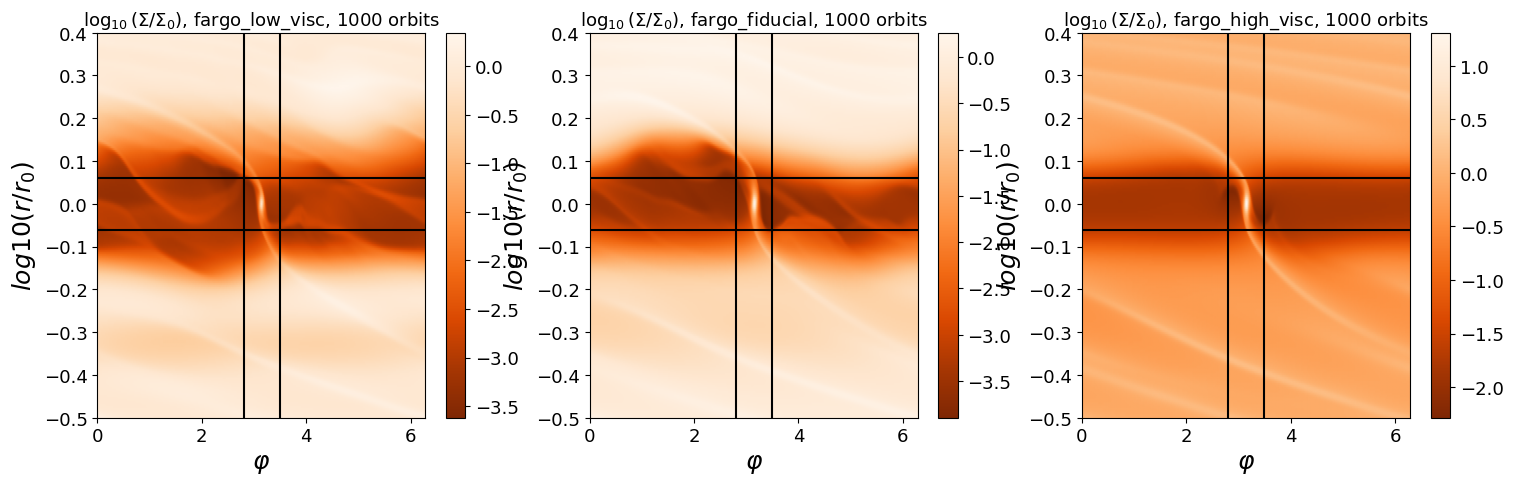

In [7]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_visc=[4,0,3]


lim = 0.5

plt.figure(figsize=(18,5))
frame = 100

for it,i in enumerate(index_for_visc):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])#,clim = (np.log10(lim+0.01),np.log10(lim-0.01)))
    plt.plot([0,np.pi*2],[r_in_log,r_in_log], color="k")
    plt.plot([0,np.pi*2],[r_out_log,r_out_log], color="k")
    plt.plot([phi_left, phi_left],[-0.5,0.8], color="k")
    plt.plot([phi_right, phi_right],[-0.5,0.8], color="k")
    
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(-0.5,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()

-0.06232656089782411


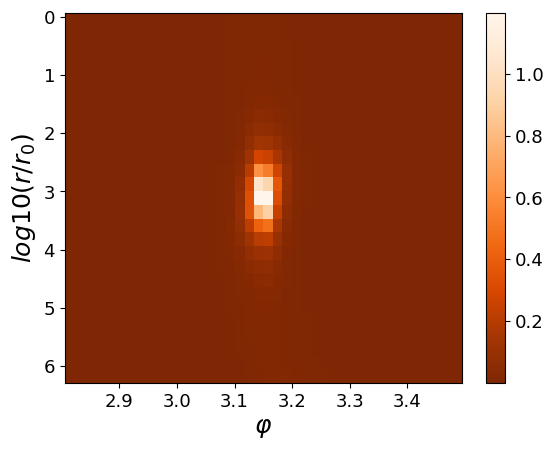

In [8]:
rho_slice = rho_cube[:,:,r_cut[0]:r_cut[1],phi_cut[0]:phi_cut[1]]
print(np.log10(r_list[r_cut[0]]))

plt.imshow(rho_slice[0][-1]/rho_slice[0][0], origin='lower', aspect='auto', cmap=cm.Oranges_r, extent=[philist[phi_cut[0]],philist[phi_cut[1]],2*np.pi, np.log10(r_list[r_cut[0]]), np.log10(r_list[r_cut[1]])])#, clim=(-3,0))
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
plt.colorbar()


# Masking

(10, 4, 300, 384)


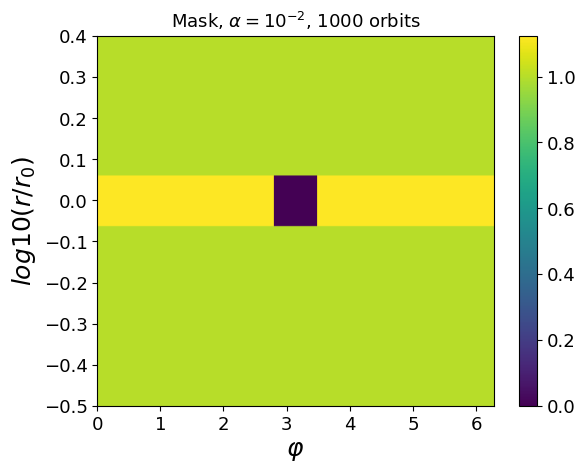

(10, 4, 300, 384)
(10, 4, 300)


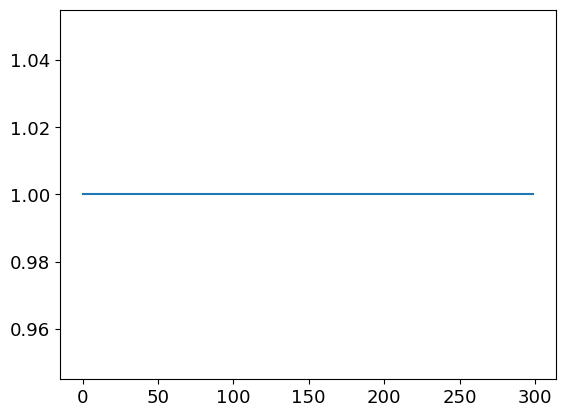

In [9]:


#rho_slice_mean = np.mean(rho_slice, axis=3)
mask = np.ones(rho_cube.shape)
print(mask.shape)
mask[:,:,r_cut[0]:r_cut[1]] = len(philist)/(len(philist)-(phi_cut[1]-phi_cut[0]))
mask[:,:,r_cut[0]:r_cut[1],phi_cut[0]:phi_cut[1]] = 0
plt.imshow(mask[1][0], aspect="auto",extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],origin="lower")
plt.ylim(-0.5,0.4)
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
plt.colorbar()
plt.title(f"Mask, {titles[i]}, {(frame)*10} orbits")
plt.savefig("img/mask1.png", bbox_inches="tight")

plt.show()

print(mask.shape)
print(np.mean(mask, axis=3).shape)
plt.plot(np.mean(mask, axis=3)[0][0])


rho_mean_clean = np.mean(rho_cube*mask, axis=3)
rho_mean = np.mean(rho_cube, axis=3)

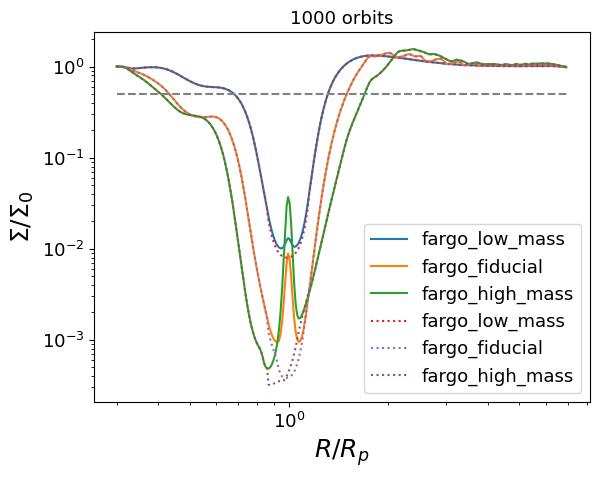

In [10]:


for i in index_for_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}")
for i in index_for_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean[i][0],linestyle="dotted",label=f"{path[43:-5]}")
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

# Irrelevant

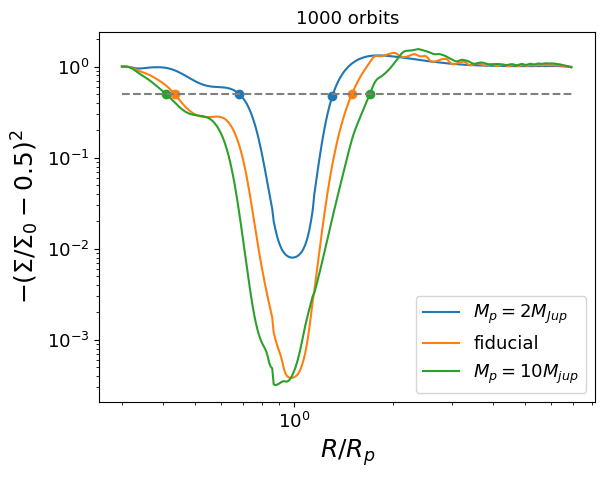

In [12]:
from uncertainties import ufloat
from scipy.signal import argrelextrema
gap_width = []

for i in index_for_mass:
    path = paths[i]
    weird = -(rho_mean_clean[i][-1]/rho_mean_clean[i][0]-0.5)**2
    
    #plt.plot(r_list,weird, label=f"{path[43:-5]}")
    local_max = argrelextrema(weird, np.greater)
    bound = []
    for l in local_max[0]:
        if weird[l]>-0.01:
            bound.append(l)
    #plt.scatter(r_list[bound],weird[bound])
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean_clean[i][0], label=f"{titles[i]}")
    plt.scatter(r_list[bound],rho_mean[i][-1][bound]/rho_mean[i][0][bound])

    r_left = ufloat(r_list[bound[0]],r_list[bound[0]+1]-r_list[bound[0]])
    r_right = ufloat(r_list[bound[1]],r_list[bound[1]+1]-r_list[bound[1]])
    gap_width.append(r_right-r_left)
    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$-(\\Sigma/\\Sigma_0 - 0.5)^2$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

[ 78 140]
[ 35 153]
[ 29 164]


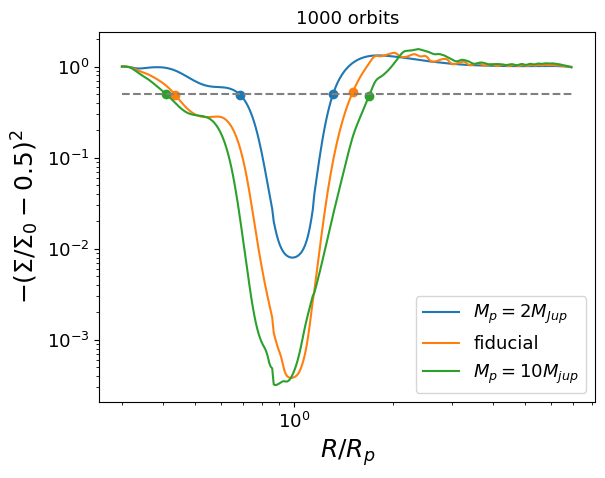

In [13]:

gap_width_sign_change = []
for i in index_for_mass:
    path = paths[i]
    weird = (rho_mean_clean[i][-1]/rho_mean_clean[i][0]-0.5)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s])/2)
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean_clean[i][0], label=f"{titles[i]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[1], r_sign_err[1])
    gap_width_sign_change.append(r_right-r_left)
    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$-(\\Sigma/\\Sigma_0 - 0.5)^2$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

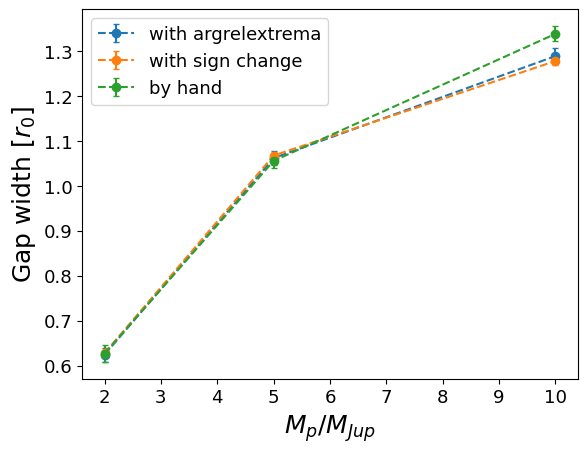

In [14]:
from uncertainties import ufloat

## make a plot for the eccentricities.
r_in_log = [ufloat(0.115,0.005),ufloat(0.14,0.005),ufloat(0.17,0.005)]
r_out_log = [ufloat(0.125,0.005),ufloat(0.20,0.005),ufloat(0.30,0.005)]
r_inner_log = [ufloat(-0.16,0.01),ufloat(-0.37,0.01),ufloat(-0.4,0.01)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)
r_inner = np.power(10,r_inner_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a

gap_width_hand = a-r_inner
w_values_h = [ee.nominal_value for ee in gap_width_hand]
w_errs_h = [ee.std_dev for ee in gap_width_hand]

w_values = [ee.nominal_value for ee in gap_width]
w_errs = [ee.std_dev for ee in gap_width]

w_values_s = [ee.nominal_value for ee in gap_width_sign_change]
w_errs_s = [ee.std_dev for ee in gap_width_sign_change]


plt.errorbar([2,5,10],w_values, yerr = w_errs, fmt="o--", capsize=2, label="with argrelextrema")

plt.errorbar([2,5,10],w_values_s, yerr = w_errs_s, fmt="o--", capsize=2, label="with sign change")
plt.errorbar([2,5,10],w_values_h, yerr = w_errs_h, fmt="o--", capsize=2, label="by hand")
plt.xlabel("$M_p/M_{Jup}$")
plt.ylabel("Gap width [$r_0$]")
plt.legend()

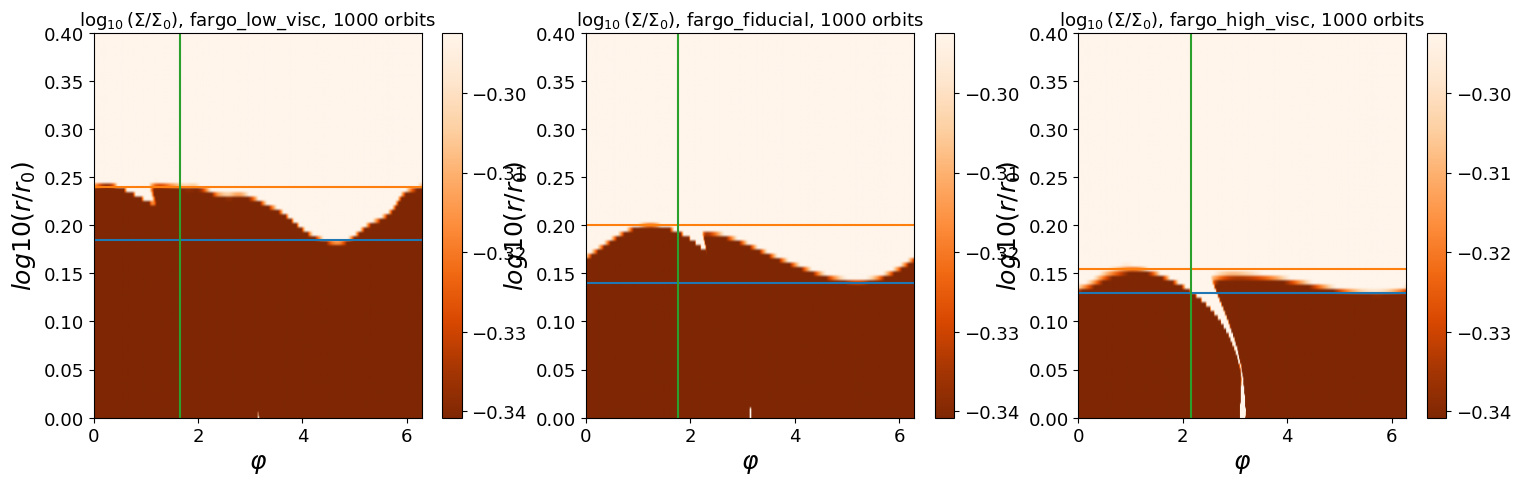

In [15]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_visc=[4,0,3]

r_in_log = [0.185,0.14,0.13]
r_out_log = [0.24,0.20,0.155]
phi_ellipse = [4.8-np.pi,4.9-np.pi,5.3-np.pi]

plt.figure(figsize=(18,5))
frame = 100

for it,i in enumerate(index_for_visc):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(0,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 1.5135612484362082
r_out: 1.7378008287493754
Eccentricity for fargo_low_visc: 0.06896788945366292


/scratch/3208986/ipykernel_3170437/1669706088.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


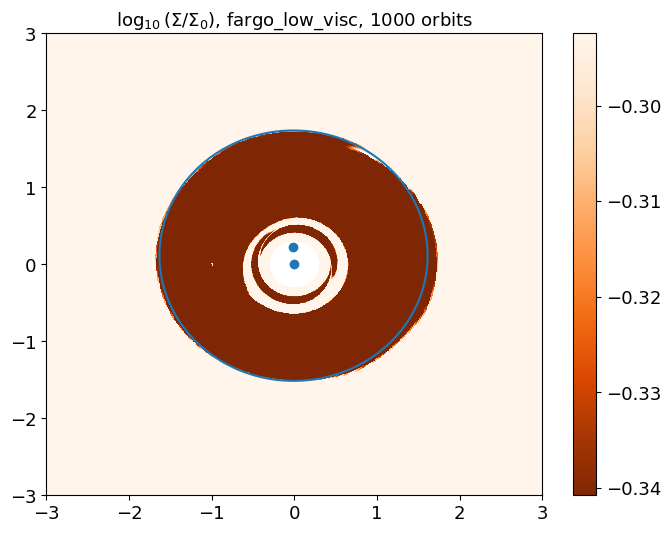

In [16]:
# index_for_mass=[2,0,1]
model_ind = index_for_visc[0]

r_in = np.power(10,0.18)
r_out = np.power(10,0.24)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.8- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

#### I just can't make this look right. That's why I'll give it large uncertainties.

r_in: 1.3489628825916535
r_out: 1.428893958511103
Eccentricity for fargo_high_visc: 0.028774368331997358


/scratch/3208986/ipykernel_3170437/2551373818.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


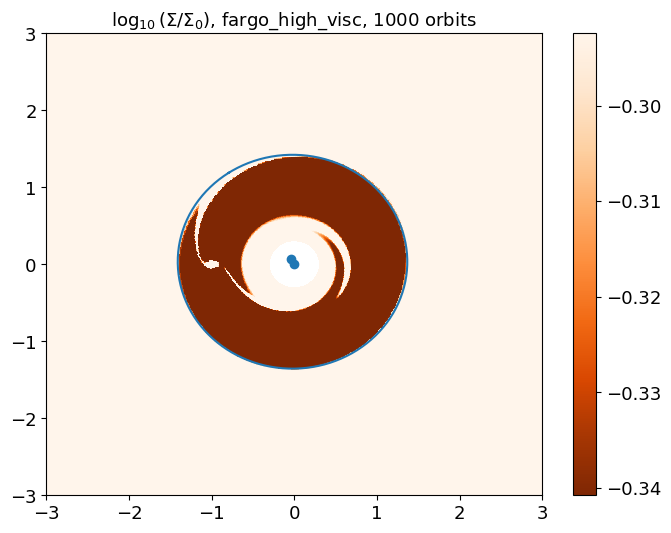

In [17]:
# index_for_mass=[2,0,1]
model_ind = index_for_visc[2]

r_in = np.power(10,0.13)
r_out = np.power(10,0.155)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.3- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

[0.06323659565621458+/-0.016216626840525494
 0.06896788945366301+/-0.008102145062480231
 0.028774368331997358+/-0.008134127319996532]


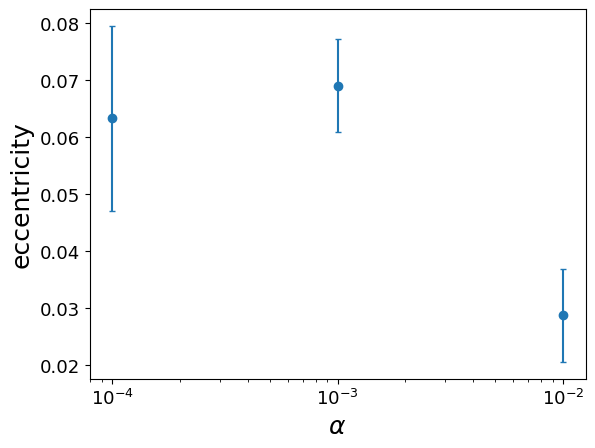

In [18]:

from uncertainties import ufloat
r_in_log = [ufloat(0.185,0.01),ufloat(0.14,0.005),ufloat(0.13,0.005)]
r_out_log = [ufloat(0.24,0.01),ufloat(0.20,0.005),ufloat(0.155,0.005)]



r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([1e-4,1e-3,1e-2],ecc_values, yerr = ecc_errs, fmt="o", capsize=2)
plt.xlabel("$\\alpha$")
plt.ylabel("eccentricity")
plt.xscale("log")

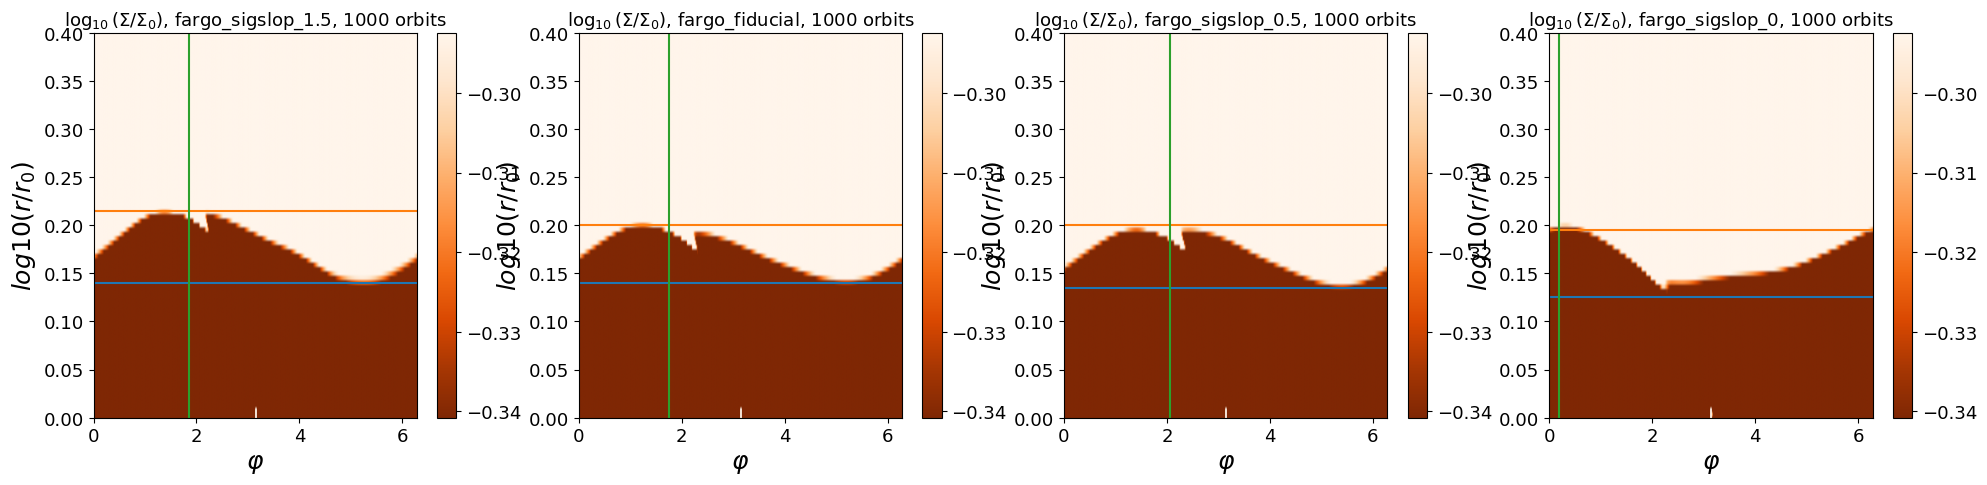

In [19]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_sigslop = [8,0,6,5]

r_in_log = [0.14,0.14,0.135,0.125]
r_out_log = [0.215,0.20,0.20,0.195]
phi_ellipse = [5.0-np.pi,4.9-np.pi,5.2-np.pi,0.2]

plt.figure(figsize=(24,5))
frame = 100

for it,i in enumerate(index_for_sigslop):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(0,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


0.14 0.215
r_in: 1.3803842646028848
r_out: 1.6405897731995394
Eccentricity for fargo_sigslop_1.5: 0.08613298404442375


/scratch/3208986/ipykernel_3170437/1228896684.py:27: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


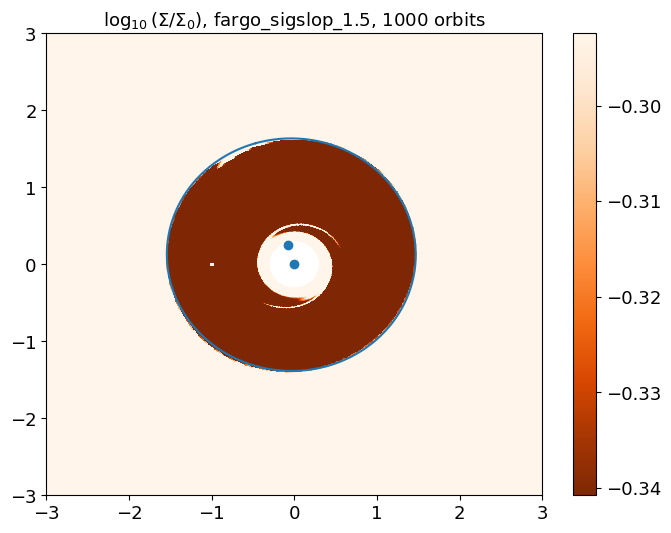

In [20]:
model_ind = index_for_sigslop[0]
print(r_in_log[0],r_out_log[0])
r_in = np.power(10,0.14)
r_out = np.power(10,0.215)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.0- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()



0.135 0.2
r_in: 1.3645831365889245
r_out: 1.5848931924611136
Eccentricity for fargo_sigslop_0.5: 0.07469463433298552


/scratch/3208986/ipykernel_3170437/742589891.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


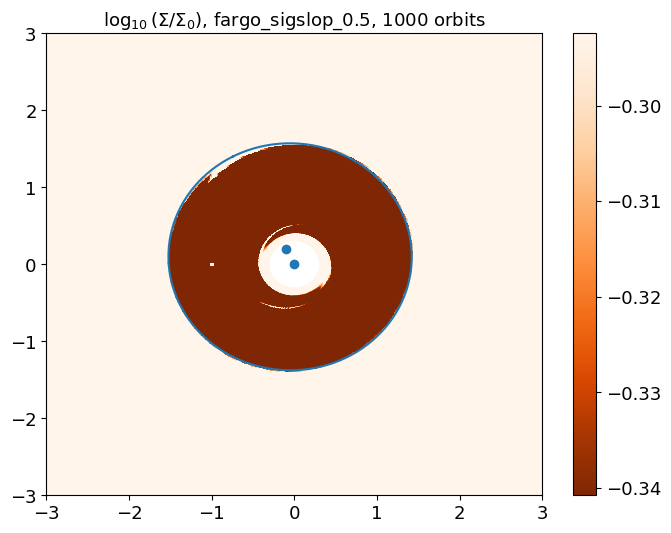

In [21]:
# index_for_mass=[2,0,1]
model_ind = index_for_sigslop[2]
print(r_in_log[2],r_out_log[2])
r_in = np.power(10,0.135)
r_out = np.power(10,0.2)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.2- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()



0.125+/-0.010 0.195+/-0.010
r_in: 1.333521432163324
r_out: 1.566751070108149
Eccentricity for fargo_sigslop_0: 0.08041645664749132


/scratch/3208986/ipykernel_3170437/3972050390.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


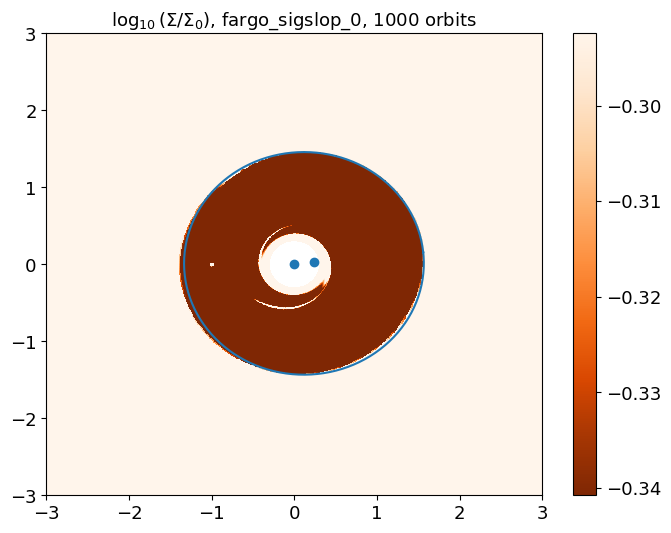

In [24]:
# index_for_mass=[2,0,1]
model_ind = index_for_sigslop[3]
print(r_in_log[3],r_out_log[3])
r_in = np.power(10,0.125)
r_out = np.power(10,0.195)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 0.1
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

#### I just can't make this look right. That's why I'll give it large uncertainties.

[0.08613298404442375+/-0.008080471458189787
 0.06896788945366301+/-0.008102145062480231
 0.07469463433298552+/-0.008095447419047249
 0.08041645664749132+/-0.016176444503259103]


Text(0, 0.5, 'eccentricity')

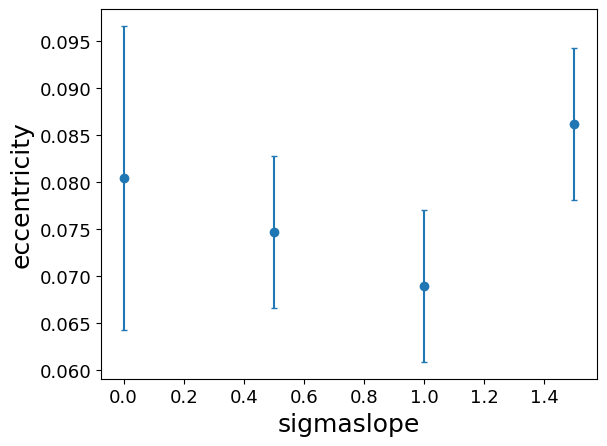

In [23]:
from uncertainties import ufloat


r_in_log = [ufloat(0.14,0.005),ufloat(0.14,0.005),ufloat(0.135,0.005),ufloat(0.125,0.01)]
r_out_log = [ufloat(0.215,0.005),ufloat(0.20,0.005),ufloat(0.20,0.005),ufloat(0.195,0.01)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([1.5,1.0,0.5,0],ecc_values, yerr = ecc_errs, fmt="o", capsize=2)
plt.xlabel("sigmaslope")
plt.ylabel("eccentricity")
#plt.xscale("log")

# Finding gap depth

/scratch/3208986/ipykernel_3170437/1853776467.py:22: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  if func[l]< gap_depth_mass[it]:


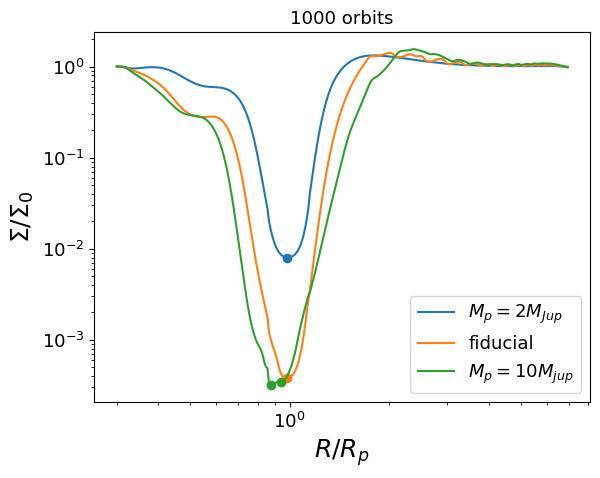

(0.0001, 0.1)

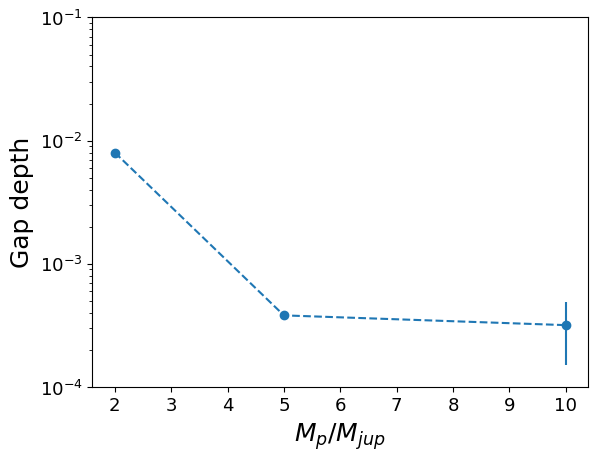

In [29]:
from uncertainties import ufloat
from scipy.signal import argrelextrema

def ufloat_arr(arr):
    values= [ee.nominal_value for ee in arr]
    errs = [ee.std_dev for ee in arr]
    return values, errs

gap_depth_mass = [1,1,1]
gap_depth_err =[0,0,0]

index_for_mass=[2,0,1]

for it,i in enumerate(index_for_mass):
    path = paths[i]
    func= (rho_mean_clean[i][-1]/rho_mean_clean[i][0])
    local_max = argrelextrema(func, np.less)
    local_max_clean = []
    for l in local_max[0]:
        if r_list[l]<1.5 and r_list[l]>0.7:
            local_max_clean.append(l)
            if func[l]< gap_depth_mass[it]:
                gap_depth_mass[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean_clean[i][0], label=f"{titles[i]}")
    plt.scatter(r_list[local_max_clean],rho_mean_clean[i][-1][local_max_clean]/rho_mean_clean[i][0][local_max_clean],)

    
#plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()
plt.savefig("img/gap_depth_mass.png", bbox_inches="tight")
plt.show()

plt.errorbar([2,5,10],ufloat_arr(gap_depth_mass)[0], yerr=ufloat_arr(gap_depth_mass)[1],linestyle="--", marker="o")
plt.yscale("log")
plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Gap depth")
plt.ylim(1e-4,1e-1)




/scratch/3208986/ipykernel_3170437/2015809315.py:14: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  if func[l]< gap_depth_visc[it]:


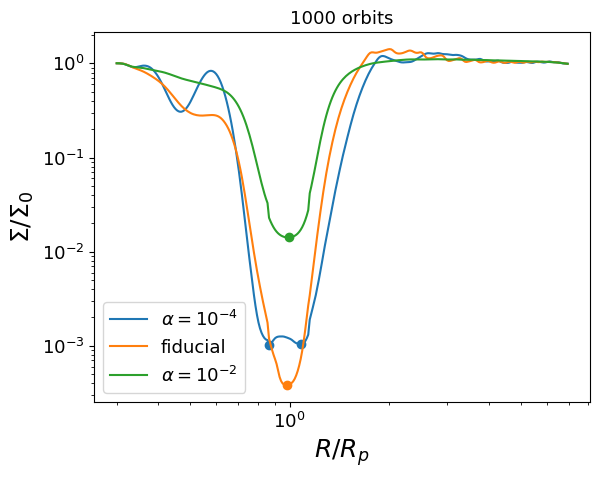

(0.0001, 0.1)

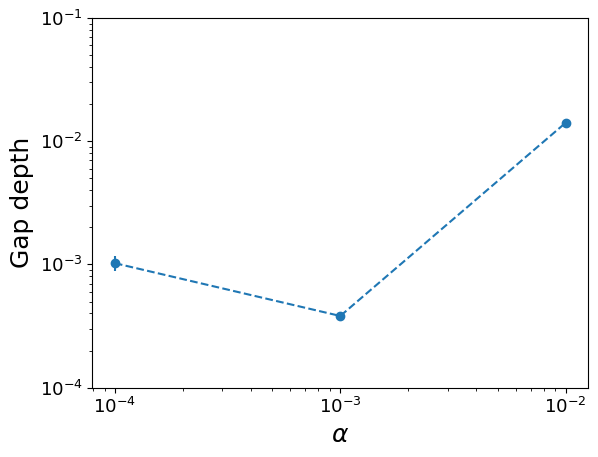

In [30]:
from scipy.signal import argrelextrema

index_for_visc=[4,0,3]
gap_depth_visc= [1,1,1]

for it,i in enumerate(index_for_visc):
    path = paths[i]
    func= (rho_mean_clean[i][-1]/rho_mean_clean[i][0])
    local_max = argrelextrema(func, np.less)
    local_max_clean = []
    for l in local_max[0]:
        if r_list[l]<1.5 and r_list[l]>0.7:
            local_max_clean.append(l)
            if func[l]< gap_depth_visc[it]:
                gap_depth_visc[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean_clean[i][0], label=f"{titles[i]}")
    plt.scatter(r_list[local_max_clean],rho_mean_clean[i][-1][local_max_clean]/rho_mean_clean[i][0][local_max_clean],)

    
#plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()
plt.savefig("img/gap_depth_visc.png", bbox_inches="tight")
plt.show()

plt.errorbar([1e-4,1e-3,1e-2],ufloat_arr(gap_depth_visc)[0], yerr=ufloat_arr(gap_depth_visc)[1],linestyle="--", marker="o")

plt.yscale("log")
plt.xscale("log")
plt.xlabel("$\\alpha$")
plt.ylabel("Gap depth")
plt.ylim(1e-4,1e-1)


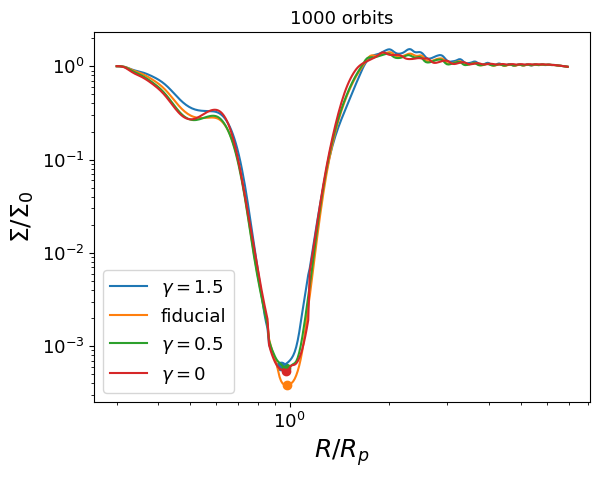

(0.0001, 0.1)

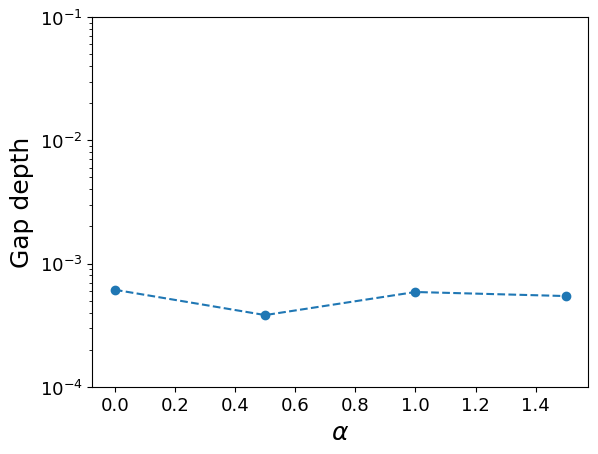

In [31]:
from scipy.signal import argrelextrema

index_for_sigslop = [8,0,6,5]
gap_depth_sigslop= [1,1,1,1]

for it,i in enumerate(index_for_sigslop):
    path = paths[i]
    func= (rho_mean_clean[i][-1]/rho_mean_clean[i][0])
    local_max = argrelextrema(func, np.less)
    local_max_clean = []
    for l in local_max[0]:
        if r_list[l]<1.5 and r_list[l]>0.7:
            local_max_clean.append(l)
            if func[l]< gap_depth_sigslop[it]:
                gap_depth_sigslop[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean_clean[i][0], label=f"{titles[i]}")
    plt.scatter(r_list[local_max_clean],rho_mean_clean[i][-1][local_max_clean]/rho_mean_clean[i][0][local_max_clean],)

    
#plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.savefig("img/gap_depth_sigslop.png", bbox_inches="tight")
plt.legend()

plt.show()
plt.errorbar([0,0.5,1.0,1.5],ufloat_arr(gap_depth_sigslop)[0], yerr=ufloat_arr(gap_depth_sigslop)[1],linestyle="--", marker="o")

plt.yscale("log")
plt.xlabel("$\\alpha$")
plt.ylabel("Gap depth")
plt.ylim(1e-4,1e-1)


# Summary

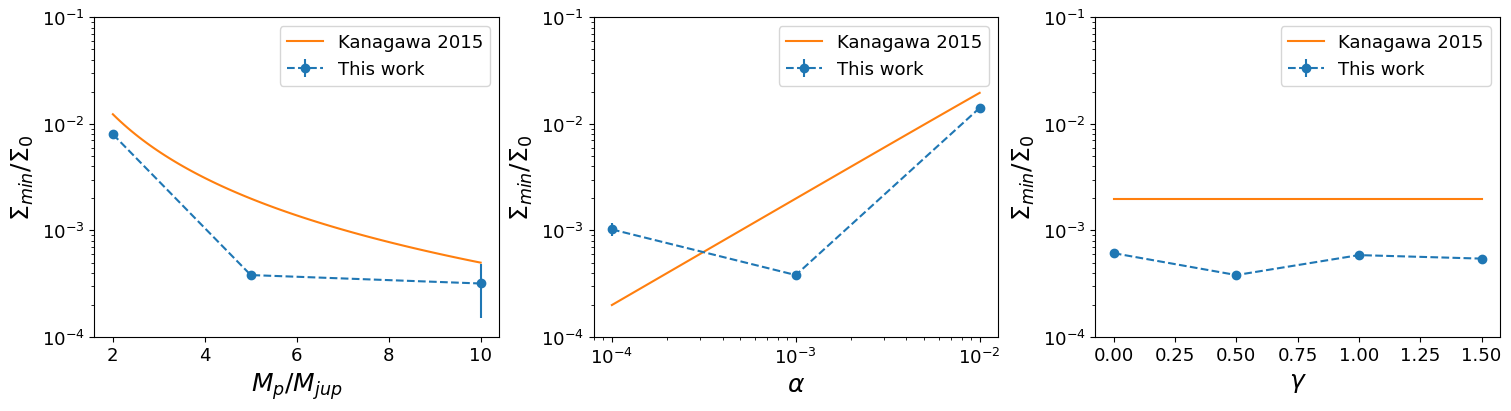

In [19]:
from uncertainties import ufloat
import matplotlib.pyplot as plt




ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
mjup = mstar*0.00177/2


def ufloat_arr(arr):
    values= [ee.nominal_value for ee in arr]
    errs = [ee.std_dev for ee in arr]
    return values, errs

plt.figure(figsize=(15,4), constrained_layout=True)

plt.subplot(1,3,1)
plt.errorbar([2,5,10],ufloat_arr(gap_depth_mass)[0], yerr=ufloat_arr(gap_depth_mass)[1],linestyle="--", marker="o",label="This work")

plt.yscale("log")
plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("$\\Sigma_{min}/\\Sigma_0$")
#plt.ylim(1e-4,1e-1)

masses = np.linspace(2,10,100)
K=np.power(masses*mjup/mstar,2)/1e-3 *(0.069)**(-5)
gap_mass_pred = 1/(1+0.04*K)

plt.plot(masses, gap_mass_pred, label="Kanagawa 2015")
plt.ylim(1e-4,1e-1)

plt.legend()


plt.subplot(1,3,2)
plt.errorbar([1e-4,1e-3,1e-2],ufloat_arr(gap_depth_visc)[0], yerr=ufloat_arr(gap_depth_visc)[1],linestyle="--", marker="o", label="This work")

plt.yscale("log")
plt.xscale("log")
plt.xlabel("$\\alpha$")
plt.ylabel("$\\Sigma_{min}/\\Sigma_0$")
plt.ylim(1e-4,1e-1)

alpha = np.linspace(1e-4,1e-2,100)
K=np.power(5*mjup/mstar,2)/alpha *(0.069)**(-5)
gap_visc_pred = 1/(1+0.04*K)

plt.plot(alpha, gap_visc_pred, label="Kanagawa 2015")
plt.legend()


plt.subplot(1,3,3)
plt.errorbar([0,0.5,1.0,1.5],ufloat_arr(gap_depth_sigslop)[0], yerr=ufloat_arr(gap_depth_sigslop)[1],linestyle="--", marker="o", label="This work")

plt.yscale("log")
plt.xlabel("$\\gamma$")
plt.ylabel("$\\Sigma_{min}/\\Sigma_0$")
plt.ylim(1e-4,1e-1)


K=np.power(5*mjup/mstar,2)/1e-3*(0.069)**(-5)
gap_pred = 1/(1+0.04*K)

plt.plot([0,1.5],[gap_pred, gap_pred], label="Kanagawa 2015")
plt.legend()
plt.savefig("img/Gap_depths.PNG")

#print(gap_width_mass[1])

In [33]:
-0.040*np.power(masses*mjup/mstar,2)/1e-3 *(0.069)**(-5)

array([  -80.12371368,   -86.72915809,   -93.59620426,  -100.72485219,
        -108.11510187,  -115.76695332,  -123.68040652,  -131.85546148,
        -140.29211821,  -148.99037669,  -157.95023692,  -167.17169892,
        -176.65476268,  -186.39942819,  -196.40569547,  -206.6735645 ,
        -217.20303529,  -227.99410784,  -239.04678215,  -250.36105822,
        -261.93693604,  -273.77441563,  -285.87349697,  -298.23418007,
        -310.85646494,  -323.74035156,  -336.88583993,  -350.29293007,
        -363.96162197,  -377.89191563,  -392.08381104,  -406.53730821,
        -421.25240714,  -436.22910783,  -451.46741028,  -466.96731449,
        -482.72882046,  -498.75192819,  -515.03663767,  -531.58294891,
        -548.39086192,  -565.46037668,  -582.7914932 ,  -600.38421147,
        -618.23853151,  -636.35445331,  -654.73197686,  -673.37110218,
        -692.27182925,  -711.43415808,  -730.85808867,  -750.54362102,
        -770.49075513,  -790.69949099,  -811.16982862,  -831.901768  ,
      

In [34]:
(0.069)**(-5)

639373.3735831913